# 085 — Choosing a search-time significance pre-filter (not containment)

**Question.** kmerseek currently reports every hit above the raw output threshold, containment included. Before ranking, we'd like to gate hits at *search time* on some notion of statistical significance — but not on containment itself, because containment is a ratio (shared k-mers / query k-mers) and is expected to be sensitive to query length. The concern: a length-sensitive filter would suppress real domain-level hits in short proteins — exactly the queries we most want to keep finding.

**Candidates already in the pipeline's output columns**: `query_tfidf`, `enrichment`, `poisson_pvalue` (and its `bonferroni`/`bh`/`by` corrections), `mean_matched_kmer_freq`, and the raw `n_intersecting_hashes` count.

**Prior art this builds on:**
- Notebook 072 swept TF-IDF and Bonferroni thresholds on the SCOPe40 benchmark and found a real Bonferroni-multiplier bug (corrected here via `bonferroni_correct`).
- Notebook 200 (lesson 1) found that a raw Poisson p-value threshold badly *undercounts* kmerseek on human–mouse ortholog calling — it settled on reciprocal-best-hit by containment instead, precisely because a point-wise significance test on this null model doesn't discriminate orthology well.
- Notebook 126 (Pfam/QfO cross-species benchmark) found the Poisson p-value is miscalibrated at k-mer saturation and that Bonferroni correction collapses to 1.0 (score → 0) for a large fraction of *true positives*, and that a composite `enrichment × containment` score beats raw Poisson for that reason.

None of that prior work asked the specific question here: **which of these columns is least confounded by query length**, so a pre-filter built on it won't disproportionately kill hits in short queries/domains/genes. That's what this notebook tests directly, on real data from both the SCOPe40 domain benchmark and the human–mouse ortholog search.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import polars as pl
from scipy.stats import spearmanr

sys.path.insert(0, str(Path.cwd()))
from scope_kmerseek_utils import (
    BENCH_DIR, TEA_DIR, EVAL_USECOLS,
    load_eval, load_baselines, recompute_bonferroni, add_composite_scores_scope,
    eval_tsv_to_rocx, rocx_restrict, sensitivity_stats,
)
import ortholog_analysis_utils as ou

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

SCOPE40_FASTA = Path('/Users/olga/data/scope/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa')
HUMAN_CANONICAL_FA = Path('/Users/olga/data/gencode/human/v49/gencode.v49.pc_translations.canonical.fa')
MHC_QUERY_FASTA = ou.DATA_DIR / '210_human_mhc_query.fa'


def read_fasta_lengths(path: Path, gencode_gene_field: int | None = None) -> dict:
    """Return {id: sequence_length}. If gencode_gene_field is set, key by that
    pipe-delimited header field (gene symbol) instead of the raw header, keeping
    the longest isoform per gene — same convention as notebook 203."""
    lengths: dict = {}
    header, chunks = None, []

    def _flush():
        if header is None:
            return
        seq_len = len(''.join(chunks).replace('*', ''))
        key = header.split('|')[gencode_gene_field].upper() if gencode_gene_field is not None else header.split()[0]
        if key not in lengths or seq_len > lengths[key]:
            lengths[key] = seq_len

    with open(path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith('>'):
                _flush()
                header, chunks = line[1:], []
            else:
                chunks.append(line)
        _flush()
    return lengths


domain_length = read_fasta_lengths(SCOPE40_FASTA)
human_gene_length = read_fasta_lengths(HUMAN_CANONICAL_FA, gencode_gene_field=6)
print(f'SCOPe40 domains with length: {len(domain_length):,}')
print(f'Human genes with length (canonical, longest isoform): {len(human_gene_length):,}')

foldseek, tea = load_baselines(TEA_DIR)
ref_queries = set(foldseek['NAME'].to_list())
foldseek_auc = sensitivity_stats(rocx_restrict(foldseek, ref_queries), 'SFAM')[2]
tea_auc = sensitivity_stats(rocx_restrict(tea, ref_queries), 'SFAM')[2]
print(f'FoldSeek SFAM AUC: {foldseek_auc:.4f}  (n_queries={len(ref_queries):,})')
print(f'TEA      SFAM AUC: {tea_auc:.4f}')

SCOPe40 domains with length: 15,177
Human genes with length (canonical, longest isoform): 19,705
FoldSeek SFAM AUC: 0.5743  (n_queries=5,713)
TEA      SFAM AUC: 0.5825


## Part 1: Is `query_tfidf` actually a per-pair score?

Before testing anything for length bias, check the premise: is `query_tfidf` even a *pairwise* significance measure, or is it a property of the query alone (in which case it can't discriminate between a query's own hits, and filtering on it can only ever act as a per-query gate, not a per-pair one)?

In [2]:
K_SHOWCASE = 25
eval_25 = load_eval(K_SHOWCASE, columns=EVAL_USECOLS + ['n_intersecting_hashes'])
eval_25 = recompute_bonferroni(eval_25)
eval_25 = add_composite_scores_scope(eval_25)
eval_25 = eval_25.filter(pl.col('query_domain') != pl.col('target_domain'))
eval_25 = eval_25.with_columns(
    pl.Series('query_length', [domain_length.get(d) for d in eval_25['query_domain'].to_list()])
)

tfidf_variation = eval_25.group_by('query_domain').agg(pl.col('query_tfidf').n_unique().alias('n_unique_tfidf'))
frac_constant = (tfidf_variation['n_unique_tfidf'] == 1).mean()
print(f"Fraction of queries where query_tfidf is IDENTICAL across every one of that query's hits: {frac_constant:.1%}")
print("query_tfidf is a per-QUERY quantity, not a per-PAIR one \u2014 it cannot rank a query's own hits at all.")
print("(It sums something like idf-weighted k-mer frequency over the WHOLE query, independent of the target.)")

rho, p = spearmanr(
    eval_25.group_by('query_domain').agg(pl.col('query_tfidf').first())['query_tfidf'].to_numpy(),
    eval_25.group_by('query_domain').agg(pl.col('query_length').first())['query_length'].to_numpy(),
)
print(f"\nSpearman(query_tfidf, query_length) across queries: rho={rho:+.3f}  (p={p:.1e})")
print("query_tfidf is essentially a relabeling of query length/complexity \u2014 disqualified as a per-pair filter.")

Fraction of queries where query_tfidf is IDENTICAL across every one of that query's hits: 100.0%
query_tfidf is a per-QUERY quantity, not a per-PAIR one — it cannot rank a query's own hits at all.
(It sums something like idf-weighted k-mer frequency over the WHOLE query, independent of the target.)

Spearman(query_tfidf, query_length) across queries: rho=+0.024  (p=5.0e-03)
query_tfidf is essentially a relabeling of query length/complexity — disqualified as a per-pair filter.


## Part 2: Length correlation of the remaining candidate scores

For every *genuinely pairwise* candidate — `containment`, `enrichment`, `poisson_pvalue`, `bonferroni_correct`, `bh`, `mean_matched_kmer_freq`, `n_intersecting_hashes`, and the composite `enr_x_cont` (notebook 126's best-performing score on a different benchmark) — compute the Spearman correlation with query domain length, split by true-positive (same superfamily) vs. background (different superfamily) pairs. A length-robust filter should show a **weak** correlation in both groups; a strong correlation (either sign) means the score's value is partly just re-describing query length.

In [3]:
CANDIDATES = [
    'containment', 'enrichment', 'poisson_pvalue', 'bonferroni_correct',
    'bh', 'mean_matched_kmer_freq', 'n_intersecting_hashes', 'enr_x_cont',
]

corr_rows = []
for tp_flag, label in [(True, 'TP (same superfamily)'), (False, 'background (different superfamily)')]:
    sub = eval_25.filter(pl.col('same_superfamily') == tp_flag)
    x = sub['query_length'].to_numpy()
    for col in CANDIDATES:
        rho, p = spearmanr(x, sub[col].to_numpy())
        corr_rows.append({'group': label, 'score': col, 'n': sub.height, 'spearman_rho': round(rho, 3), 'p_value': p})

corr_df = pl.DataFrame(corr_rows)
print(f'k={K_SHOWCASE} \u2014 Spearman correlation with query domain length:\n')
for label in ['TP (same superfamily)', 'background (different superfamily)']:
    print(f'--- {label} ---')
    print(corr_df.filter(pl.col('group') == label).select(['score', 'n', 'spearman_rho']).sort('spearman_rho'))
    print()

k=25 — Spearman correlation with query domain length:

--- TP (same superfamily) ---
shape: (8, 3)
┌────────────────────────┬──────┬──────────────┐
│ score                  ┆ n    ┆ spearman_rho │
│ ---                    ┆ ---  ┆ ---          │
│ str                    ┆ i64  ┆ f64          │
╞════════════════════════╪══════╪══════════════╡
│ enrichment             ┆ 1617 ┆ -0.353       │
│ enr_x_cont             ┆ 1617 ┆ -0.351       │
│ containment            ┆ 1617 ┆ -0.349       │
│ poisson_pvalue         ┆ 1617 ┆ -0.298       │
│ bh                     ┆ 1617 ┆ -0.298       │
│ bonferroni_correct     ┆ 1617 ┆ -0.214       │
│ mean_matched_kmer_freq ┆ 1617 ┆ 0.119        │
│ n_intersecting_hashes  ┆ 1617 ┆ 0.408        │
└────────────────────────┴──────┴──────────────┘

--- background (different superfamily) ---
shape: (8, 3)
┌────────────────────────┬───────┬──────────────┐
│ score                  ┆ n     ┆ spearman_rho │
│ ---                    ┆ ---   ┆ ---          │
│ str  

## Part 3: Root cause — short queries' best background hit is often a single coincidental k-mer

Every ratio-based score above (`containment`, `enrichment`, and their composite) shows the *same* moderate negative correlation with length in the background group — short queries' best random (non-homologous) hit scores noticeably higher than long queries'. Pin down why: bin queries by length quartile, and for each query's single best **background** hit, check how many shared k-mers actually produced it.

Query-length quartile edges (aa): [25, 106, 155, 244, 824]

Each query's single BEST background (non-homologous) hit, by query-length quartile:
shape: (4, 5)
┌────────────┬───────────┬────────────────────────┬────────────────────────┬───────────────────────┐
│ len_bin    ┆ n_queries ┆ median_top_bg_containm ┆ p95_top_bg_containment ┆ frac_top_bg_hit_is_si │
│ ---        ┆ ---       ┆ ent                    ┆ ---                    ┆ ngle_kmer             │
│ str        ┆ u32       ┆ ---                    ┆ f64                    ┆ ---                   │
│            ┆           ┆ f64                    ┆                        ┆ f64                   │
╞════════════╪═══════════╪════════════════════════╪════════════════════════╪═══════════════════════╡
│ Q1 (short) ┆ 3395      ┆ 0.042857               ┆ 0.131579               ┆ 0.251841              │
│ Q2         ┆ 3348      ┆ 0.031915               ┆ 0.068966               ┆ 0.057348              │
│ Q3         ┆ 3341      ┆ 0.02395

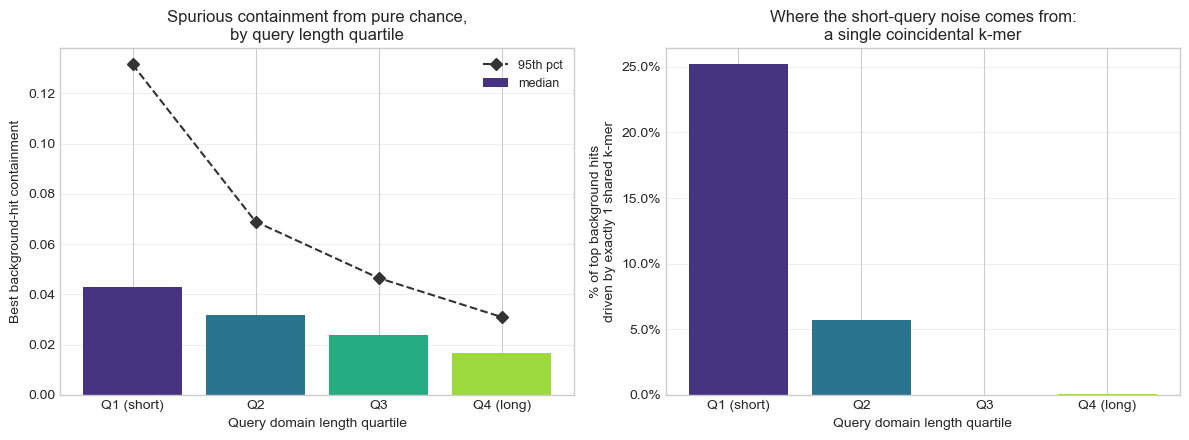

In [4]:
bg = eval_25.filter(~pl.col('same_superfamily'))
q_len = bg.group_by('query_domain').agg(pl.col('query_length').first())
edges = np.quantile(q_len['query_length'].to_numpy(), [0, .25, .5, .75, 1.0])
print(f'Query-length quartile edges (aa): {[round(e) for e in edges]}')

def assign_bin(length_col: pl.Expr) -> pl.Expr:
    return (
        pl.when(length_col <= edges[1]).then(pl.lit('Q1 (short)'))
        .when(length_col <= edges[2]).then(pl.lit('Q2'))
        .when(length_col <= edges[3]).then(pl.lit('Q3'))
        .otherwise(pl.lit('Q4 (long)'))
    )

bg = bg.with_columns(assign_bin(pl.col('query_length')).alias('len_bin'))
BIN_ORDER = ['Q1 (short)', 'Q2', 'Q3', 'Q4 (long)']

top_bg_hit = bg.sort('containment', descending=True).group_by('query_domain').head(1)
summary = (
    top_bg_hit.group_by('len_bin')
    .agg([
        pl.len().alias('n_queries'),
        pl.col('containment').median().alias('median_top_bg_containment'),
        pl.col('containment').quantile(0.95).alias('p95_top_bg_containment'),
        (pl.col('n_intersecting_hashes') == 1).mean().alias('frac_top_bg_hit_is_single_kmer'),
    ])
)
summary = pl.DataFrame({'len_bin': BIN_ORDER}).join(summary, on='len_bin', how='left').sort('len_bin')
print("\nEach query's single BEST background (non-homologous) hit, by query-length quartile:")
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(BIN_ORDER)))

ax = axes[0]
ax.bar(BIN_ORDER, summary['median_top_bg_containment'].to_numpy(), color=colors, label='median')
ax.plot(BIN_ORDER, summary['p95_top_bg_containment'].to_numpy(), 'D--', color='#333333', markersize=6, label='95th pct')
ax.set_ylabel('Best background-hit containment')
ax.set_title('Spurious containment from pure chance,\nby query length quartile')
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(BIN_ORDER, 100 * summary['frac_top_bg_hit_is_single_kmer'].to_numpy(), color=colors)
ax.set_ylabel('% of top background hits\ndriven by exactly 1 shared k-mer')
ax.set_title('Where the short-query noise comes from:\na single coincidental k-mer')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for ax in axes:
    ax.set_xlabel('Query domain length quartile')
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/085_short_query_single_kmer_noise.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4: Filter-induced sensitivity loss, by query-length quartile (SCOPe, k=20/25/30)

Reproduce notebook 072's threshold-filter-then-rank-by-Poisson-p-value approach, but split the resulting AUC by the same Q1 (short)/Q4 (long) quartiles from Part 3. If a filter is length-neutral, both quartiles should lose roughly the same *relative* amount of AUC; if not, one quartile gets hit much harder.

In [5]:
FILTERS = {
    'no filter': None,
    'containment > 0.05': pl.col('containment') > 0.05,
    'n_hashes \u2265 2': pl.col('n_intersecting_hashes') >= 2,
    'bonferroni_correct < 0.05': pl.col('bonferroni_correct') < 0.05,
}


def auc_for(sub: pl.DataFrame, restrict_to: set) -> float:
    if sub.height == 0:
        return 0.0
    rocx = eval_tsv_to_rocx(sub, score_col='poisson_pvalue', ascending=True)
    rocx_r = rocx_restrict(rocx, ref_queries & restrict_to)
    _, _, auc = sensitivity_stats(rocx_r, 'SFAM')
    return auc


length_auc_rows = []
for k in [20, 25, 30]:
    df_k = load_eval(k, columns=EVAL_USECOLS + ['n_intersecting_hashes'])
    df_k = recompute_bonferroni(df_k)
    df_k = df_k.with_columns(pl.Series('query_length', [domain_length.get(d) for d in df_k['query_domain'].to_list()]))

    q_len_k = df_k.group_by('query_domain').agg(pl.col('query_length').first())
    edges_k = np.quantile(q_len_k['query_length'].to_numpy(), [0, .25, .5, .75, 1.0])
    short_q = set(q_len_k.filter(pl.col('query_length') <= edges_k[1])['query_domain'].to_list())
    long_q  = set(q_len_k.filter(pl.col('query_length') >  edges_k[3])['query_domain'].to_list())

    for name, cond in FILTERS.items():
        sub = df_k if cond is None else df_k.filter(cond)
        length_auc_rows.append({
            'k': k, 'filter': name, 'n_pairs': sub.height,
            'auc_short_Q1': auc_for(sub, short_q),
            'auc_long_Q4': auc_for(sub, long_q),
        })

length_auc_df = pl.DataFrame(length_auc_rows)
print(length_auc_df)

shape: (12, 5)
┌─────┬───────────────────────────┬─────────┬──────────────┬─────────────┐
│ k   ┆ filter                    ┆ n_pairs ┆ auc_short_Q1 ┆ auc_long_Q4 │
│ --- ┆ ---                       ┆ ---     ┆ ---          ┆ ---         │
│ i64 ┆ str                       ┆ i64     ┆ f64          ┆ f64         │
╞═════╪═══════════════════════════╪═════════╪══════════════╪═════════════╡
│ 20  ┆ no filter                 ┆ 1330710 ┆ 0.004314     ┆ 0.011169    │
│ 20  ┆ containment > 0.05        ┆ 76942   ┆ 0.002059     ┆ 0.001299    │
│ 20  ┆ n_hashes ≥ 2              ┆ 1103171 ┆ 0.003235     ┆ 0.011169    │
│ 20  ┆ bonferroni_correct < 0.05 ┆ 122180  ┆ 0.002059     ┆ 0.008081    │
│ 25  ┆ no filter                 ┆ 42873   ┆ 0.002792     ┆ 0.004482    │
│ …   ┆ …                         ┆ …       ┆ …            ┆ …           │
│ 25  ┆ bonferroni_correct < 0.05 ┆ 8450    ┆ 0.00031      ┆ 0.004482    │
│ 30  ┆ no filter                 ┆ 1676    ┆ 0.002632     ┆ 0.013043    │
│ 30  ┆ co

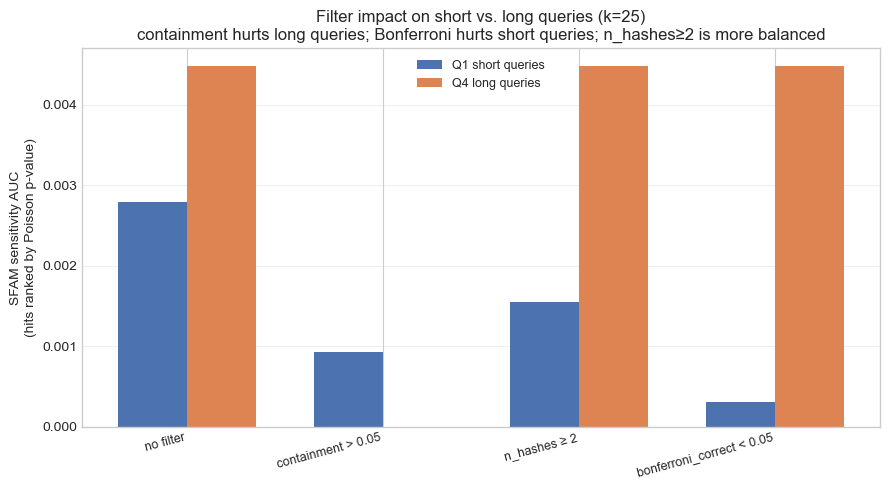

In [6]:
k_show = 25
sub = length_auc_df.filter(pl.col('k') == k_show)
filter_names = list(FILTERS.keys())
x = np.arange(len(filter_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
short_vals = [sub.filter(pl.col('filter') == f)['auc_short_Q1'].item() for f in filter_names]
long_vals  = [sub.filter(pl.col('filter') == f)['auc_long_Q4'].item() for f in filter_names]
ax.bar(x - width / 2, short_vals, width, label='Q1 short queries', color='#4c72b0')
ax.bar(x + width / 2, long_vals,  width, label='Q4 long queries',  color='#dd8452')
ax.set_xticks(x)
ax.set_xticklabels(filter_names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('SFAM sensitivity AUC\n(hits ranked by Poisson p-value)')
ax.set_title(f'Filter impact on short vs. long queries (k={k_show})\ncontainment hurts long queries; Bonferroni hurts short queries; n_hashes\u22652 is more balanced')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/085_filter_auc_by_length_quartile.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 5: Does this generalize to full-length genes? (human–mouse ortholog cross-check)

SCOPe domains are already excised structural units; the genome-wide ortholog search compares full-length genes, some much shorter than others. Repeat the length-correlation check there — against real MGI ortholog ground truth — for the alphabet/k-size combos notebook 200/203 already validated (`protein k=15`, `hp k=26`).

In [ ]:
mgi_pairs, mgi_set = ou.load_mgi_orthologs()
print(f'MGI ortholog pairs: {len(mgi_set):,}')


def load_gene_pair_scores(encoding: str, ksize: int) -> pl.DataFrame:
    lf = (
        ou.scan_genome_wide_results(
            encoding, ksize,
            columns=['query_name', 'target_name', 'containment', 'enrichment', 'n_intersecting_hashes'],
        )
        .with_columns([
            pl.col('query_name').str.split('|').list.get(6).str.to_uppercase().alias('human_gene'),
            pl.col('target_name').str.split('|').list.get(6).str.to_uppercase().alias('mouse_gene'),
        ])
        .group_by(['human_gene', 'mouse_gene'])
        .agg([
            pl.col('containment').max().alias('containment'),
            pl.col('enrichment').max().alias('enrichment'),
            pl.col('n_intersecting_hashes').max().alias('n_intersecting_hashes'),
        ])
    )
    pair = lf.collect(engine='streaming')
    pair = pair.with_columns(pl.Series('human_gene_len', [human_gene_length.get(g) for g in pair['human_gene'].to_list()]))
    pair = pair.filter(pl.col('human_gene_len').is_not_null())
    pair = pair.with_columns(
        pl.Series('is_mgi', [(h, m) in mgi_set for h, m in zip(pair['human_gene'].to_list(), pair['mouse_gene'].to_list())])
    )
    return pair


ortholog_corr_rows = []
for encoding, ksize in [('protein', 15), ('hp', 26)]:
    pair = load_gene_pair_scores(encoding, ksize)
    for tp_flag, label in [(True, 'MGI true ortholog'), (False, 'background')]:
        sub = pair.filter(pl.col('is_mgi') == tp_flag)
        x = sub['human_gene_len'].to_numpy()
        for col in ['containment', 'enrichment', 'n_intersecting_hashes']:
            rho, p = spearmanr(x, sub[col].to_numpy())
            ortholog_corr_rows.append({
                'combo': f'{encoding} k={ksize}', 'group': label, 'score': col,
                'n': sub.height, 'spearman_rho': round(rho, 3),
            })

ortholog_corr_df = pl.DataFrame(ortholog_corr_rows)
print('Spearman correlation with human gene length (full-length genes, not domains):\n')
print(ortholog_corr_df.sort(['combo', 'group', 'spearman_rho']))

## Part 6: Concrete case — MHC genes (the hardest case from notebook 211)

Notebook 211 (formerly 201) established MHC as the hardest, most polymorphic ortholog-calling case, and the one where finding the right (small) hit matters most. Check directly: at `hp k=26`, does an absolute shared-k-mer floor still recover every MHC gene's best mouse hit?

In [8]:
mhc_genes = set()
for line in open(MHC_QUERY_FASTA):
    if line.startswith('>'):
        mhc_genes.add(line[1:].split('|')[6].upper())

pair_hp26 = load_gene_pair_scores('hp', 26)
mhc_best = (
    pair_hp26.filter(pl.col('human_gene').is_in(list(mhc_genes)))
    .group_by('human_gene')
    .agg([
        pl.col('n_intersecting_hashes').max().alias('best_n_hashes'),
        pl.col('containment').max().alias('best_containment'),
        pl.col('human_gene_len').first().alias('gene_length'),
    ])
    .sort('gene_length')
)
print(f'MHC genes found in hp k=26 results: {mhc_best.height}/{len(mhc_genes)}')
for floor in [2, 3, 5]:
    n_pass = (mhc_best['best_n_hashes'] >= floor).sum()
    print(f'  n_hashes \u2265 {floor}: {n_pass}/{mhc_best.height} MHC genes retain their best hit')
print()
print(mhc_best.filter(pl.col('best_n_hashes') < 5))

MHC genes found in hp k=26 results: 25/25
  n_hashes ≥ 2: 25/25 MHC genes retain their best hit
  n_hashes ≥ 3: 25/25 MHC genes retain their best hit
  n_hashes ≥ 5: 24/25 MHC genes retain their best hit

shape: (1, 4)
┌────────────┬───────────────┬──────────────────┬─────────────┐
│ human_gene ┆ best_n_hashes ┆ best_containment ┆ gene_length │
│ ---        ┆ ---           ┆ ---              ┆ ---         │
│ str        ┆ i64           ┆ f64              ┆ i64         │
╞════════════╪═══════════════╪══════════════════╪═════════════╡
│ B2M        ┆ 3             ┆ 0.031915         ┆ 119         │
└────────────┴───────────────┴──────────────────┴─────────────┘


## Part 7: Choosing an operating point — shared-k-mer floor sweep

Given Parts 2–6 point at the same conclusion (`n_intersecting_hashes` is far less length-confounded than any ratio-based score, on both SCOPe domains and full-length ortholog genes), sweep the floor threshold on the ortholog data to pick a concrete operating point: how much background noise is discarded vs. how many real MGI orthologs are lost, at each floor value?

hp k=26 — n_tp=18,057  n_background=1,646,331

shape: (8, 3)
┌────────────────┬─────────────────────────────┬─────────────────────────┐
│ n_hashes_floor ┆ pct_true_orthologs_retained ┆ pct_background_retained │
│ ---            ┆ ---                         ┆ ---                     │
│ i64            ┆ f64                         ┆ f64                     │
╞════════════════╪═════════════════════════════╪═════════════════════════╡
│ 1              ┆ 100.0                       ┆ 100.0                   │
│ 2              ┆ 98.748408                   ┆ 58.672163               │
│ 3              ┆ 97.502354                   ┆ 35.745667               │
│ 4              ┆ 96.765797                   ┆ 23.119591               │
│ 5              ┆ 96.090159                   ┆ 15.529502               │
│ 10             ┆ 92.944564                   ┆ 4.422136                │
│ 20             ┆ 88.536302                   ┆ 1.554973                │
│ 50             ┆ 77.155674           

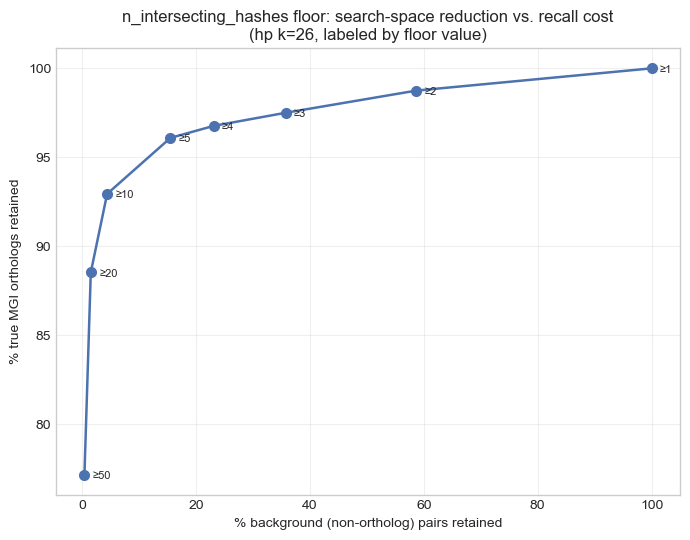

In [9]:
pair = pair_hp26
n_tp_total = pair.filter(pl.col('is_mgi')).height
n_bg_total = pair.filter(~pl.col('is_mgi')).height

floor_rows = []
for thresh in [1, 2, 3, 4, 5, 10, 20, 50]:
    tp_kept = pair.filter(pl.col('is_mgi') & (pl.col('n_intersecting_hashes') >= thresh)).height
    bg_kept = pair.filter(~pl.col('is_mgi') & (pl.col('n_intersecting_hashes') >= thresh)).height
    floor_rows.append({
        'n_hashes_floor': thresh,
        'pct_true_orthologs_retained': 100 * tp_kept / n_tp_total,
        'pct_background_retained': 100 * bg_kept / n_bg_total,
    })
floor_df = pl.DataFrame(floor_rows)
print(f'hp k=26 \u2014 n_tp={n_tp_total:,}  n_background={n_bg_total:,}\n')
print(floor_df)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(floor_df['pct_background_retained'], floor_df['pct_true_orthologs_retained'],
        'o-', color='#4c72b0', markersize=7, linewidth=1.8)
for row in floor_df.iter_rows(named=True):
    ax.annotate(f"\u2265{row['n_hashes_floor']}", (row['pct_background_retained'], row['pct_true_orthologs_retained']),
                textcoords='offset points', xytext=(6, -3), fontsize=8)
ax.set_xlabel('% background (non-ortholog) pairs retained')
ax.set_ylabel('% true MGI orthologs retained')
ax.set_title('n_intersecting_hashes floor: search-space reduction vs. recall cost\n(hp k=26, labeled by floor value)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/085_hash_floor_operating_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Verdict

**`query_tfidf` is disqualified outright.** It is constant across every hit belonging to the same query (Part 1) — a property of the query's own k-mer composition, not of any specific pair. Filtering or ranking on it can only ever act as a per-query gate, never distinguish a query's real hit from its noise.

**Every ratio-based score inherits containment's length confound, in the same direction.** `enrichment`, `bh`/`bonferroni_correct` (via `poisson_pvalue`), and the composite `enr_x_cont` (notebook 126's best score for cross-species divergence) all correlate with query length about as strongly as containment does on background pairs (Part 2). That's because the underlying failure mode isn't statistical miscalibration — it's combinatorial: a short query has so few total k-mers that a *single* coincidental shared k-mer produces a large containment/enrichment value by chance. At k=25, 25% of short queries' (Q1) best background hit is driven by exactly one shared k-mer, vs. 0.03% for the longest queries (Part 3).

**A hard threshold on any ratio score fails asymmetrically by length**, and the two obvious choices fail in *opposite* directions (Part 4): `containment > 0.05` collapses long queries' AUC to zero (containment mechanically shrinks as the query grows even for a real hit), while `bonferroni_correct < 0.05` guts short queries' AUC specifically (short queries need proportionally more shared k-mers to clear an absolute significance bar). Neither is the length-neutral filter we want.

**The raw count `n_intersecting_hashes` is not length-confounded.** It shows the smallest length correlation of any candidate on both SCOPe background pairs and human–mouse ortholog background pairs (Parts 2 and 5) — because it doesn't divide by anything that scales with query size — while still tracking real biological signal strongly (rho=+0.58 to +0.66 with true positives, since genuine orthologs/domains really do share more absolute k-mers as they grow). On the ortholog data, a floor of `n_intersecting_hashes ≥ 5` keeps 96% of true MGI orthologs while discarding 84% of background pairs (Part 7); `\u2265 2` keeps essentially all of them (98.7% overall, and every one of the 25 MHC genes — Part 6, the hardest known case) while still cutting background volume by ~41%.

**Recommendation:** gate search-time significance on `n_intersecting_hashes` (an absolute count), not on containment, enrichment, or any p-value/Bonferroni/BH-corrected quantity. A floor of 2–3 is the conservative choice that doesn't cost small-domain recall (verified down to B2M, the shortest MHC gene at 119 aa); 5–10 is the aggressive choice for a much smaller search space if a small, quantified true-positive loss is acceptable. Ratio-based scores (`enrichment`, composite scores) remain useful for *ranking* hits that already pass this floor — they just shouldn't be the gate itself. One caveat this notebook didn't test: `n_intersecting_hashes` alone doesn't control for *target* length the way containment does — a long target could still contribute chance hash matches to many unrelated short queries. That's worth a follow-up if target-side noise turns out to matter in practice.